<a href="https://colab.research.google.com/github/AkankshaB123/forecasting/blob/main/Time_Series_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Move fast. Build Intuition

In [76]:
#Libraries
import pandas as pd

In [78]:
#Load the data - German Store
df = pd.read_csv('/content/drive/MyDrive/Python - Time Series Forecasting/train.csv')
df.head()

/tmp/ipython-input-1030304963.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Python - Time Series Forecasting/train.csv')


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [80]:
df['StateHoliday'].value_counts()

,count
StateHoliday,
0,855087
0,131072
a,20260
b,6690
c,4100


In [81]:
#Binarize(0,1) the 'StateHoliday' column
df['StateHoliday'] = df['StateHoliday'].apply(lambda x: 1 if x == 'a' or x == 'b' or x == 'c' else 0)

In [82]:
df['StateHoliday'].value_counts()

,count
StateHoliday,
0,986159
1,31050


# Subsetting Stores and Basic Aggregations

In [83]:
print(f"There are {len(df.Store.unique())} stores")

There are 1115 stores


isin() below - returns True or False only

In [87]:
#Subset the data to 10 random stores (seed=1502) and store the result in df_10
df_10 = df[df['Store'].isin(df.Store.sample(n=10, random_state=1502))].copy()
df_10

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
23,24,5,2015-07-31,14190,1082,1,1,0,1
46,47,5,2015-07-31,9379,1021,1,1,0,1
155,156,5,2015-07-31,8828,821,1,1,0,1
263,264,5,2015-07-31,8303,992,1,1,0,1
266,267,5,2015-07-31,11326,1217,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1016447,353,2,2013-01-01,3139,820,1,0,1,1
1016857,763,2,2013-01-01,0,0,0,0,1,1
1016888,794,2,2013-01-01,0,0,0,0,1,1
1016956,862,2,2013-01-01,0,0,0,0,1,1


In [88]:
df.Store.sample(10, random_state = 1502)

,Store
363239,763
798693,24
56611,862
899066,47
996288,264
812316,267
75498,794
601470,156
814028,864
725432,353


In [89]:
df_10.groupby('Store')['Sales'].mean().sort_values(ascending=False)

,Sales
Store,
24,7763.773885
267,7731.106157
862,7128.519108
47,5946.666667
264,5851.901274
156,5779.171975
353,5579.376858
763,5097.873673
864,3520.780255


# All-time highest sales stores

In [91]:
#For each store, find the index (row) of the day with the all-time highest sales.
df_10.groupby('Store')['Sales'].idxmax().sort_values(ascending=False)
#Insight: 866 did highest sales.

,Sales
Store,
864,947828
862,627821
156,627115
763,619917
264,455513
24,408443
794,245456
267,245014
353,101817


# 3. Working with Datetime

In [92]:
df_10.groupby(['DayOfWeek','Store'])['Sales'].mean()

DayOfWeek  Store
1          24       10860.119403
           47        7877.686567
           156       8707.940299
           264       8320.291045
           267       8969.253731
                        ...     
7          353       7255.343284
           763          0.000000
           794          0.000000
           862          0.000000
           864          0.000000
Name: Sales, Length: 70, dtype: float64

In [116]:
df_10.groupby([pd.to_datetime(df_10['Date']).dt.dayofweek,'Store'])['Sales'].mean()

Date  Store
0     24       10860.119403
      47        7877.686567
      156       8707.940299
      264       8320.291045
      267       8969.253731
                   ...     
6     353       7255.343284
      763          0.000000
      794          0.000000
      862          0.000000
      864          0.000000
Name: Sales, Length: 70, dtype: float64

In [95]:
df_10.groupby([pd.to_datetime(df_10['Date']).dt.dayofweek,'Store'])['Sales'].mean().unstack()

Store,24,47,156,264,267,353,763,794,862,864
Date,,,,,,,,,,
0,10860.119403,7877.686567,8707.940299,8320.291045,8969.253731,5713.537313,6706.805970,3273.238806,9628.335821,4808.111940
1,9440.622222,7432.837037,7734.370370,7288.022222,8100.214815,5289.637037,5800.962963,3081.200000,9135.007407,4510.192593
2,9069.733333,7318.274074,6697.540741,6537.200000,7894.911111,5236.229630,5747.474074,2933.548148,8193.325926,4406.585185
3,8225.370370,6705.177778,7562.481481,6381.592593,9383.177778,5503.029630,5588.459259,3009.466667,8077.503704,3998.859259
4,9348.022222,6636.696296,6593.725926,6450.037037,8588.666667,5736.792593,6101.414815,3085.088889,8330.244444,4233.340741
5,7365.022388,5623.858209,3117.313433,5961.917910,11158.813433,4325.186567,5718.753731,2477.641791,6496.246269,2665.492537
6,0.000000,0.000000,0.000000,0.000000,0.000000,7255.343284,0.000000,0.000000,0.000000,0.000000


<Axes: xlabel='Date'>

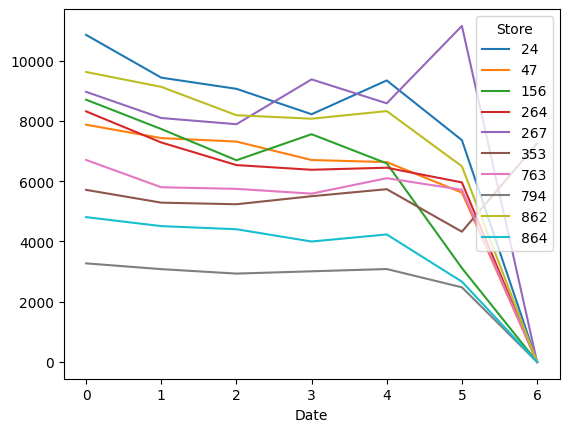

In [96]:
df_10.groupby([pd.to_datetime(df_10['Date']).dt.dayofweek,'Store'])['Sales'].mean().unstack().plot()

# 4. Standardizing Sales and Comparing WeekDay Patterns

z = (x-mean)/sd

where x is the original value, mu is mean, sd - standard deviation

In [99]:
#Define a function that standardizes a numeric Series using z-scores.
def standardize(series):
  return (series - series.mean())/series.std()

In [100]:
#Standardize the 'Sales' column within each store
df_10.loc[:,'Sales_standardized'] = df_10.groupby('Store')['Sales'].transform(standardize)
df_10.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Sales_standardized
23,24,5,2015-07-31,14190,1082,1,1,0,1,1.504863
46,47,5,2015-07-31,9379,1021,1,1,0,1,1.103818
155,156,5,2015-07-31,8828,821,1,1,0,1,0.832283
263,264,5,2015-07-31,8303,992,1,1,0,1,0.697361
266,267,5,2015-07-31,11326,1217,1,1,0,1,0.853360


In [101]:
#Compute the mean of standarized sales per weekday and per store.
df_10.groupby([pd.to_datetime(df_10['Date']).dt.dayofweek,'Store'])['Sales_standardized'].mean().unstack()

Store,24,47,156,264,267,353,763,794,862,864
Date,,,,,,,,,,
0,0.725087,0.621004,0.799508,0.702281,0.293913,0.085719,0.613992,0.563718,0.666669,0.675971
1,0.392676,0.477943,0.533739,0.408590,0.087619,-0.185123,0.268309,0.413313,0.535105,0.519535
2,0.305823,0.441101,0.250700,0.194974,0.038884,-0.219246,0.247897,0.297673,0.283970,0.465132
3,0.108094,0.243933,0.486816,0.150702,0.392171,-0.048780,0.187215,0.357132,0.253082,0.251037
4,0.370992,0.221909,0.222361,0.170175,0.203569,0.100577,0.382966,0.416359,0.320485,0.374162
5,-0.093378,-0.103813,-0.726646,0.031301,0.813673,-0.801337,0.236937,-0.059393,-0.168619,-0.449107
6,-1.818083,-1.912412,-1.577624,-1.664922,-1.835219,1.070822,-1.945422,-1.999880,-1.901085,-1.848743


<Axes: xlabel='DayOfWeek'>

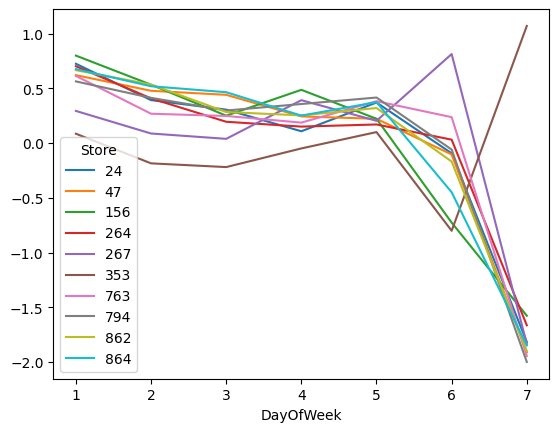

In [102]:
df_10.groupby(['DayOfWeek','Store'])['Sales_standardized'].mean().unstack().plot()

# Analyzing on Specific Weekday




In [110]:
df_d7

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Sales_standardized
5598,24,7,2015-07-26,0,0,0,0,0,0,-1.818083
5621,47,7,2015-07-26,0,0,0,0,0,0,-1.912412
5730,156,7,2015-07-26,0,0,0,0,0,0,-1.577624
5838,264,7,2015-07-26,0,0,0,0,0,0,-1.664922
5841,267,7,2015-07-26,0,0,0,0,0,0,-1.835219
...,...,...,...,...,...,...,...,...,...,...
1010872,353,7,2013-01-06,3930,1068,1,0,1,0,-1.053833
1011282,763,7,2013-01-06,0,0,0,0,0,0,-1.945422
1011313,794,7,2013-01-06,0,0,0,0,0,0,-1.999880
1011381,862,7,2013-01-06,0,0,0,0,0,0,-1.901085


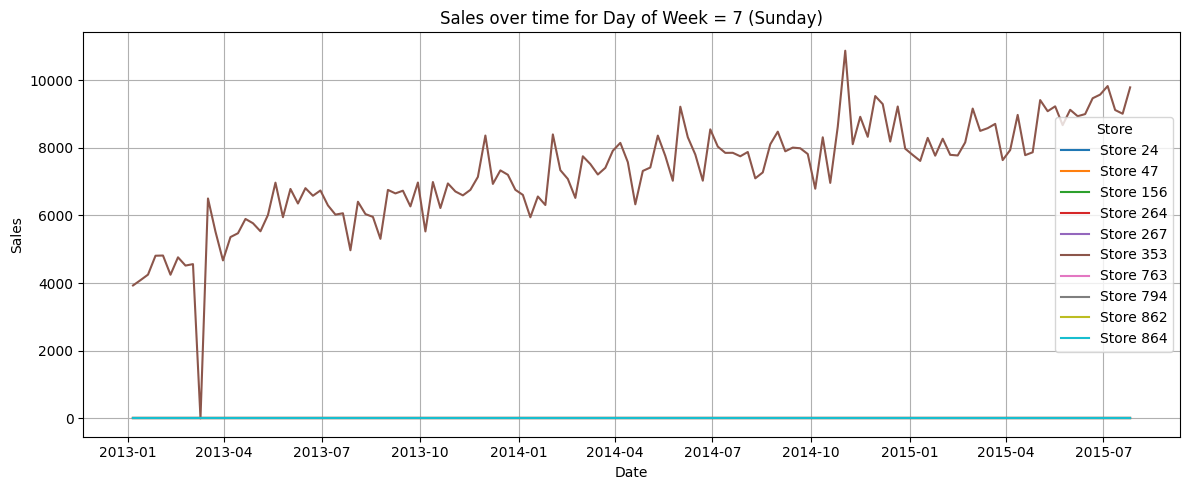

In [121]:
#Filter data to dayofweek = 7 and visualize sales over time for each store.
import matplotlib.pyplot as plt

df_d7 = df_10[df_10['DayOfWeek'] == 7].copy()

# Ensure 'Date' column is datetime type for proper plotting
df_d7['Date'] = pd.to_datetime(df_d7['Date'])

plt.figure(figsize = (12,5))
for store, data in df_d7.groupby('Store'):
  plt.plot(data['Date'], data.Sales, label = f'Store {store}')

plt.title('Sales over time for Day of Week = 7 (Sunday)')
plt.xlabel('Date')
plt.ylabel('Sales')
#plt.xticks(rotation=45) # Rotate x-axis labels
plt.legend(title='Store')
plt.grid(True)
plt.tight_layout()
plt.show()

By Including Sunday we are including 'noise'

# Removing Outliers and Re-Assessing Intra-Week Seasonality

In [122]:
#Remove observations of DayofWeek = 7 and for Store 353 and create a cleaned DataFrame
df_d7_cleaned = df_10[(df_10['DayOfWeek'] != 7) & (df_10['Store'] != 353)].copy()
df_d7_cleaned

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Sales_standardized
23,24,5,2015-07-31,14190,1082,1,1,0,1,1.504863
46,47,5,2015-07-31,9379,1021,1,1,0,1,1.103818
155,156,5,2015-07-31,8828,821,1,1,0,1,0.832283
263,264,5,2015-07-31,8303,992,1,1,0,1,0.697361
266,267,5,2015-07-31,11326,1217,1,1,0,1,0.853360
...,...,...,...,...,...,...,...,...,...,...
1016361,267,2,2013-01-01,0,0,0,0,1,1,-1.835219
1016857,763,2,2013-01-01,0,0,0,0,1,1,-1.945422
1016888,794,2,2013-01-01,0,0,0,0,1,1,-1.999880
1016956,862,2,2013-01-01,0,0,0,0,1,1,-1.901085


In [123]:
#Re-standardize the 'Sales' column within each store in df_clean.
df_d7_cleaned.loc[:,'Sales_standardized'] = df_d7_cleaned.groupby('Store')['Sales'].transform(standardize)
df_d7_cleaned

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Sales_standardized
23,24,5,2015-07-31,14190,1082,1,1,0,1,1.658935
46,47,5,2015-07-31,9379,1021,1,1,0,1,1.162338
155,156,5,2015-07-31,8828,821,1,1,0,1,0.689866
263,264,5,2015-07-31,8303,992,1,1,0,1,0.530960
266,267,5,2015-07-31,11326,1217,1,1,0,1,0.765726
...,...,...,...,...,...,...,...,...,...,...
1016361,267,2,2013-01-01,0,0,0,0,1,1,-2.984181
1016857,763,2,2013-01-01,0,0,0,0,1,1,-3.445182
1016888,794,2,2013-01-01,0,0,0,0,1,1,-3.724863
1016956,862,2,2013-01-01,0,0,0,0,1,1,-3.245322


In [124]:
#Compute the mean of standardized sales per weekday and per store in df_clean
df_d7_cleaned.groupby([pd.to_datetime(df_d7_cleaned['Date']).dt.dayofweek,'Store'])['Sales_standardized'].mean().unstack()

Store,24,47,156,264,267,763,794,862,864
Date,,,,,,,,,
0,0.583938,0.448952,0.650245,0.537160,-0.014565,0.442577,0.370730,0.514525,0.520087
1,0.125676,0.237571,0.328951,0.166980,-0.302294,-0.082517,0.130444,0.321881,0.299821
2,0.005941,0.183134,-0.013220,-0.102272,-0.370267,-0.113523,-0.054303,-0.045844,0.223219
3,-0.266648,-0.108194,0.272225,-0.158074,0.122480,-0.205699,0.040688,-0.091072,-0.078232
4,0.095782,-0.140735,-0.047480,-0.133529,-0.140573,0.091647,0.135310,0.007623,0.095131
5,-0.544397,-0.622010,-1.194753,-0.308573,0.710373,-0.130171,-0.624750,-0.708550,-1.064054


In [126]:
intra_week = df_d7_cleaned.groupby([pd.to_datetime(df_d7_cleaned['Date']).dt.dayofweek,'Store'])['Sales_standardized'].mean().unstack()

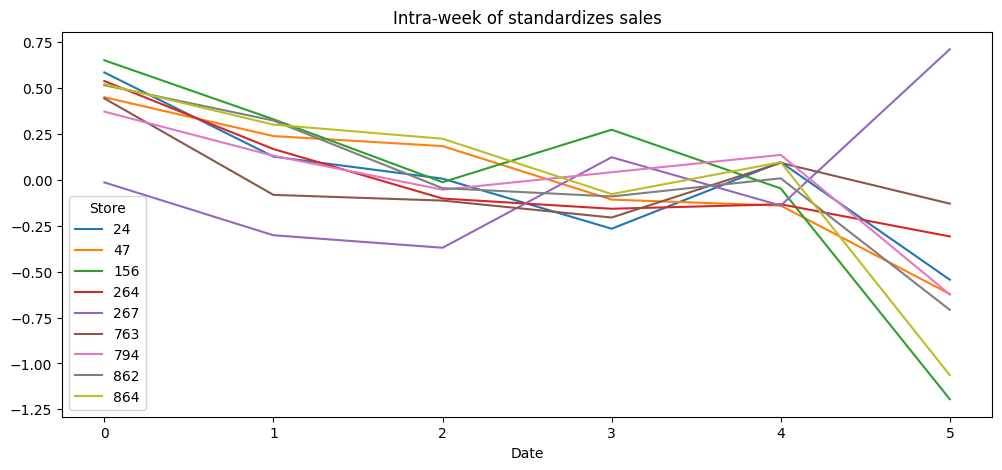

In [130]:
#Visualize the intra-week seasonality using the standardized sales
intra_week.plot(figsize=(12,5),
                title = 'Intra-week of standardizes sales')
plt.show()

* Monday always the strongest, Sat is the weakest

# Analyzing the Impact of Promotions (EDA persp.)

* Revenue planning
* Demand planning

In [131]:
#Compare average sales on promotion days versus non-promotion days.
df.groupby('Promo')['Sales'].mean()

,Sales
Promo,
0,4406.050805
1,7991.152046


In [133]:
#Compute the mean sales per store split by promotion status and store the result in promo
promo_uplift = df.groupby(['Store','Promo'])['Sales'].mean().unstack()
promo_uplift

Promo,0,1
Store,,
1,3198.994845,5152.886111
2,2855.058419,6172.816667
3,3967.596220,8608.666667
4,6568.939863,10370.511111
5,2582.271478,5944.266667
...,...,...
1111,3073.487973,6395.294444
1112,5975.537801,12490.363889
1113,4400.362543,7320.086111


In [ ]:
#For each store, compute the relative uplift of sales during non-promotions days

In [135]:
promo_uplift['diff'] = promo_uplift[1] - promo_uplift[0]/promo_uplift[0]
promo_uplift

Promo,0,1,diff
Store,,,
1,3198.994845,5152.886111,5151.886111
2,2855.058419,6172.816667,6171.816667
3,3967.596220,8608.666667,8607.666667
4,6568.939863,10370.511111,10369.511111
5,2582.271478,5944.266667,5943.266667
...,...,...,...
1111,3073.487973,6395.294444,6394.294444
1112,5975.537801,12490.363889,12489.363889
1113,4400.362543,7320.086111,7319.086111


Highest elasticity

In [138]:
#Identify top 5 largest stores with the highest relative promotion uplift
promo_uplift['diff'].nlargest(5)

,diff
Store,
817,24678.566667
1114,21600.497222
262,20990.536111
251,20669.544444
562,20081.855556


Lowest elasticity

In [139]:
#Identiy the 5 stores with the lowest (or most negative) relative promotion uplift.
promo_uplift['diff'].nsmallest(5)

,diff
Store,
794,3169.780556
208,3249.997222
254,3360.252778
789,3404.797222
307,3498.763889


There are confounding variables, whenever promo wouldn't explain  
* Breadth of promo/offers
* Depth of discount
* More & More discounts, products